In [ ]:
# Step 1 — Libraries check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib imported successfully")

NumPy version: 2.5.1
Pandas version: 3.0.5
Matplotlib imported successfully
Sab theek hai!


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("TensorFlow ready hai!")

TensorFlow version: 2.21.0
Keras version: 3.15.1
TensorFlow ready hai!


In [8]:
import os
dataset_path = "PlantVillage"  
folders = os.listdir(dataset_path)
print("Saare folders:")
for folder in folders:
    print(" ", folder)

Saare folders:
  Tomato_Spider_mites_Two_spotted_spider_mite
  Potato___healthy
  Tomato__Tomato_YellowLeaf__Curl_Virus
  Tomato_Early_blight
  Potato___Late_blight
  Tomato_Late_blight
  Pepper__bell___healthy
  Tomato_Bacterial_spot
  Potato___Early_blight
  Tomato_Septoria_leaf_spot
  Tomato__Tomato_mosaic_virus
  Tomato_healthy
  Tomato__Target_Spot
  Tomato_Leaf_Mold
  Pepper__bell___Bacterial_spot


In [9]:
classes = ["Tomato_Early_blight", "Tomato_Late_blight", "Tomato_healthy"]
print("Class-wise image count:")
print("-" * 35)

for cls in classes:
    folder_path = os.path.join(dataset_path, cls)
    images = os.listdir(folder_path)
    print(f"{cls}: {len(images)} images")

Class-wise image count:
-----------------------------------
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_healthy: 1591 images


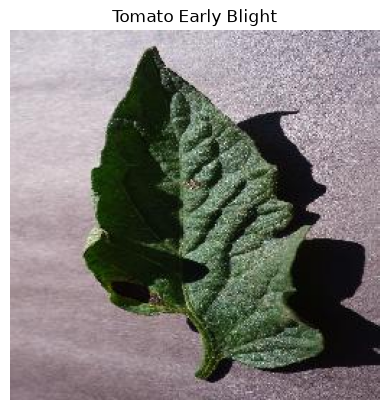

Image shape: (256, 256, 3)
Image file: 468a0f48-b0c4-4969-9f21-826cb3ae3f61___RS_Erly.B 7725.JPG


In [10]:
import matplotlib.image as mpimg
img_path = os.path.join(dataset_path, "Tomato_Early_blight")
first_image = os.listdir(img_path)[0]
full_path = os.path.join(img_path, first_image)
img = mpimg.imread(full_path)
plt.imshow(img)
plt.title("Tomato Early Blight")
plt.axis("off")
plt.show()
print("Image shape:", img.shape)
print("Image file:", first_image)

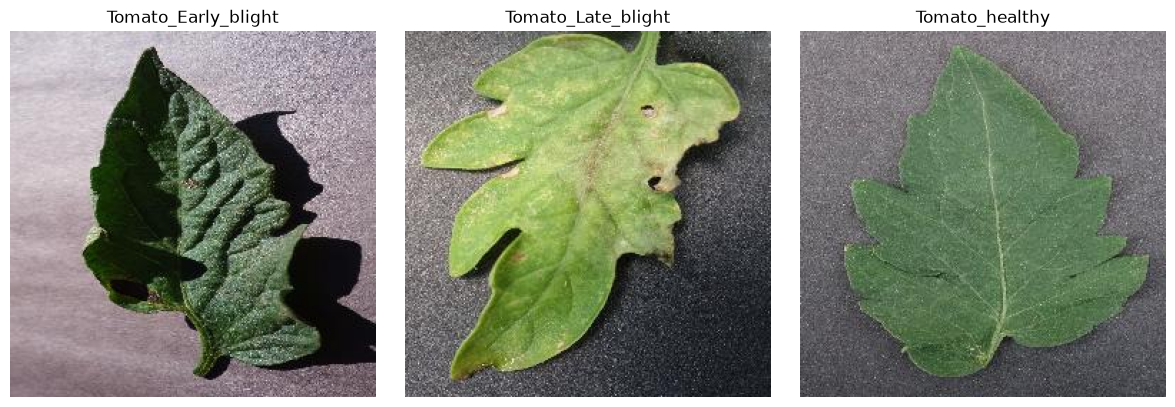

In [11]:
plt.figure(figsize=(12, 4))

for i, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    first_img = os.listdir(folder)[0]
    img_path = os.path.join(folder, first_img)
    img = mpimg.imread(img_path)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

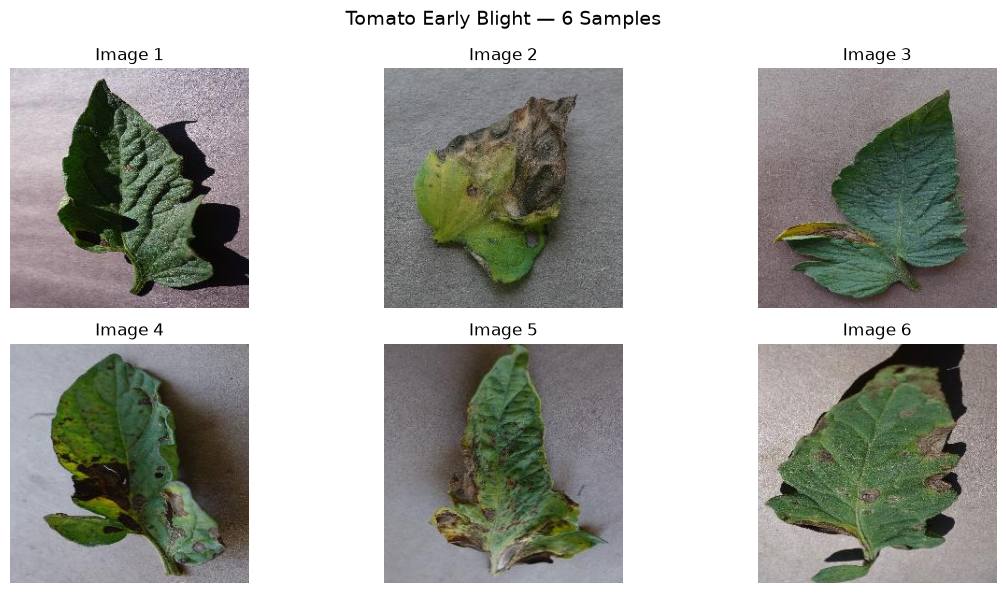

In [12]:
folder = os.path.join(dataset_path, "Tomato_Early_blight")

images = os.listdir(folder)[:6]  # pehli 6 images

plt.figure(figsize=(12, 6))

for i, img_name in enumerate(images):
    img_path = os.path.join(folder, img_name)
    img = mpimg.imread(img_path)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.suptitle("Tomato Early Blight — 6 Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image


IMG_SIZE = 128   # Images ko 128x128 mein resize karenge

X = []   # Images
y = []   # Labels (0, 1, 2)

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    print(f"Loading {cls}... (label = {label})")
    
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
            img_array = image.img_to_array(img)
            X.append(img_array)
            y.append(label)
        except:
            pass  # Corrupt image skip

X = np.array(X)
y = np.array(y)

print("\n✅ Loading complete!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Loading Tomato_Early_blight... (label = 0)
Loading Tomato_Late_blight... (label = 1)
Loading Tomato_healthy... (label = 2)

✅ Loading complete!
X shape: (4500, 128, 128, 3)
y shape: (4500,)


In [14]:
unique, counts = np.unique(y, return_counts=True)

print("Label distribution:")
print("-" * 30)
for label, count in zip(unique, counts):
    class_name = ["Early Blight", "Late Blight", "Healthy"][label]
    print(f"Label {label} ({class_name}): {count} images")

print("\nTotal:", len(y))
print("X min pixel value:", X.min())
print("X max pixel value:", X.max())

Label distribution:
------------------------------
Label 0 (Early Blight): 1000 images
Label 1 (Late Blight): 1909 images
Label 2 (Healthy): 1591 images

Total: 4500
X min pixel value: 0.0
X max pixel value: 255.0


In [15]:
# Step 11 — Normalize + One-Hot Encoding
from tensorflow.keras.utils import to_categorical

# 1. Normalize (0-255 → 0-1)
X = X.astype("float32") / 255.0

# 2. One-hot encode labels (3 classes)
y_encoded = to_categorical(y, num_classes=3)

print("After normalization:")
print("X min:", X.min())
print("X max:", X.max())
print()
print("After one-hot encoding:")
print("y_encoded shape:", y_encoded.shape)
print()
print("Example — pehla label:")
print("Original y[0]:", y[0])
print("Encoded y_encoded[0]:", y_encoded[0])

After normalization:
X min: 0.0
X max: 1.0

After one-hot encoding:
y_encoded shape: (4500, 3)

Example — pehla label:
Original y[0]: 0
Encoded y_encoded[0]: [1. 0. 0.]


In [16]:
# Step 12 — Data ko 3 parts mein todo
from sklearn.model_selection import train_test_split

# Pehle: Train (70%) aur Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, 
    test_size=0.30, 
    random_state=42,
    stratify=y_encoded   # Balanced split
)

# Phir: Temp ko Validation (15%) aur Test (15%) mein todo
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Data Split Complete!")
print("-" * 40)
print(f"Training set:    {X_train.shape}  →  {len(X_train)} images")
print(f"Validation set:  {X_val.shape}    →  {len(X_val)} images")
print(f"Test set:        {X_test.shape}   →  {len(X_test)} images")
print("-" * 40)
print(f"Total: {len(X_train) + len(X_val) + len(X_test)}")

Data Split Complete!
----------------------------------------
Training set:    (3150, 128, 128, 3)  →  3150 images
Validation set:  (675, 128, 128, 3)    →  675 images
Test set:        (675, 128, 128, 3)   →  675 images
----------------------------------------
Total: 4500


In [17]:
# Step 13 — CNN Model Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(128, 128, 3)),
    
    # Block 1
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Fully Connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')   # 3 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Step 14 — Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")
print()
print("Optimizer: Adam")
print("Loss:      Categorical Crossentropy (3 classes)")
print("Metric:    Accuracy")

✅ Model compiled successfully!

Optimizer: Adam
Loss:      Categorical Crossentropy (3 classes)
Metric:    Accuracy


In [19]:
# Step 15 — Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

print("\n✅ Training complete!")

W0000 00:00:1786312022.158763   20222 cpu_allocator_impl.cc:82] Allocation of 619315200 exceeds 10% of free system memory.


Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.6562 - loss: 0.7134

W0000 00:00:1786312083.491920   20222 cpu_allocator_impl.cc:82] Allocation of 132710400 exceeds 10% of free system memory.


99/99 ━━━━━━━━━━━━━━━━━━━━ 62s 584ms/step - accuracy: 0.6562 - loss: 0.7134 - val_accuracy: 0.7985 - val_loss: 0.4176
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 56s 569ms/step - accuracy: 0.8206 - loss: 0.4120 - val_accuracy: 0.8281 - val_loss: 0.3600
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 556ms/step - accuracy: 0.8581 - loss: 0.3182 - val_accuracy: 0.8281 - val_loss: 0.3658
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - accuracy: 0.8781 - loss: 0.2858 - val_accuracy: 0.8711 - val_loss: 0.2594
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 55s 551ms/step - accuracy: 0.8857 - loss: 0.2672 - val_accuracy: 0.8815 - val_loss: 0.2323
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 51s 513ms/step - accuracy: 0.9000 - loss: 0.2413 - val_accuracy: 0.8963 - val_loss: 0.2211
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 472ms/step - accuracy: 0.9162 - loss: 0.2038 - val_accuracy: 0.8963 - val_loss: 0.2550
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 473ms/step - accuracy: 0.9165 - loss: 0.2174 - val_accuracy: 0.905

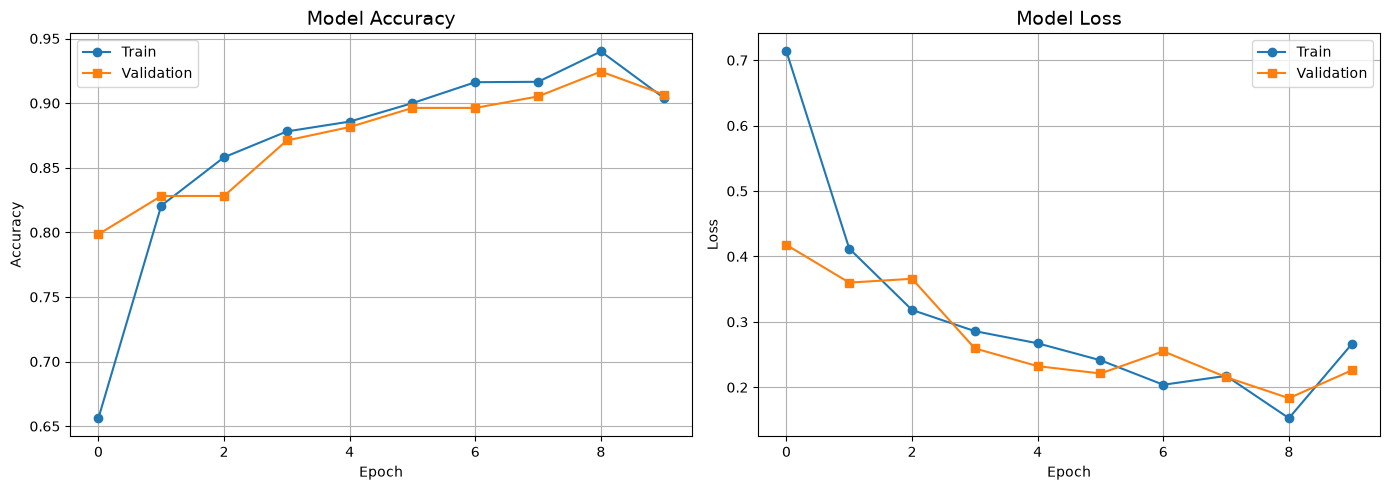

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Step 17 — Test set evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n" + "="*40)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy*100:.2f}%")
print("="*40)

W0000 00:00:1786312653.494011   20222 cpu_allocator_impl.cc:82] Allocation of 132710400 exceeds 10% of free system memory.


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9185 - loss: 0.1978

Test Loss:      0.1978
Test Accuracy:  91.85%


W0000 00:00:1786312716.896922   20222 cpu_allocator_impl.cc:82] Allocation of 132710400 exceeds 10% of free system memory.


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step


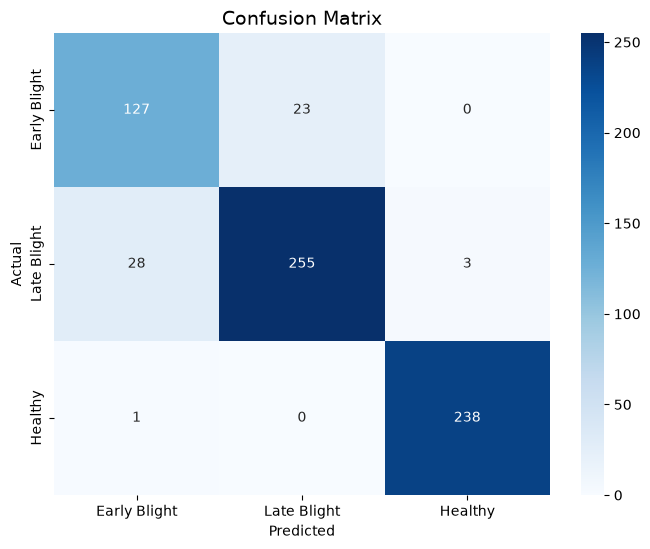


Classification Report:
              precision    recall  f1-score   support

Early Blight       0.81      0.85      0.83       150
 Late Blight       0.92      0.89      0.90       286
     Healthy       0.99      1.00      0.99       239

    accuracy                           0.92       675
   macro avg       0.91      0.91      0.91       675
weighted avg       0.92      0.92      0.92       675



In [23]:
# Step 18 — Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Early Blight', 'Late Blight', 'Healthy']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print("="*55)
print(classification_report(y_true, y_pred, target_names=class_names))

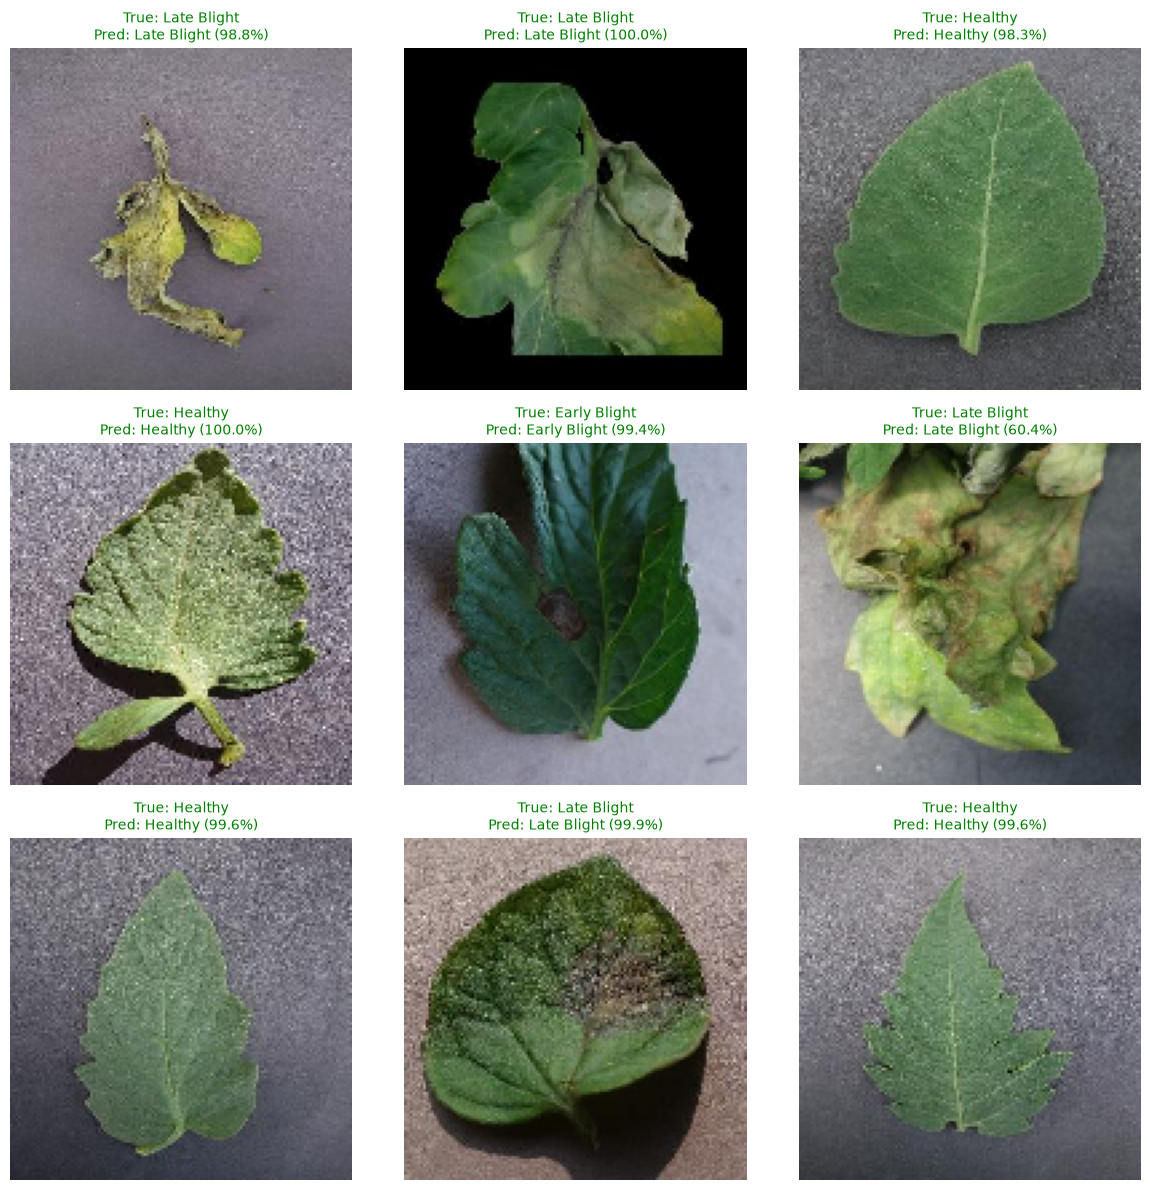

In [24]:

class_names = ['Early Blight', 'Late Blight', 'Healthy']

# 9 random images
indices = np.random.choice(len(X_test), 9, replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):
    img = X_test[idx]
    true_label = class_names[np.argmax(y_test[idx])]
    pred_probs = model.predict(img.reshape(1, 128, 128, 3), verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_label else 'red'
    
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Step 20 — Save the model
model.save("plant_disease_model.keras")

print("✅ Model saved successfully!")
print("📁 File: plant_disease_model.keras")

# File size check
import os
size_mb = os.path.getsize("plant_disease_model.keras") / (1024 * 1024)
print(f"📊 Size: {size_mb:.2f} MB")

✅ Model saved successfully!
📁 File: plant_disease_model.keras
📊 Size: 37.87 MB


In [26]:
# Step 21 — Data Augmentation setup
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data ke liye augmentation
train_datagen = ImageDataGenerator(
    rotation_range=25,        # 25 degrees tak rotate
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift
    zoom_range=0.15,          # Zoom in/out
    horizontal_flip=True,     # Mirror flip
    fill_mode='nearest'       # Empty spots fill
)

# Validation/Test data ke liye NO augmentation
val_datagen = ImageDataGenerator()

# Generators create karo
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

print("✅ Data augmentation ready!")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches:   {len(val_generator)}")

✅ Data augmentation ready!
Train batches: 99
Val batches:   22


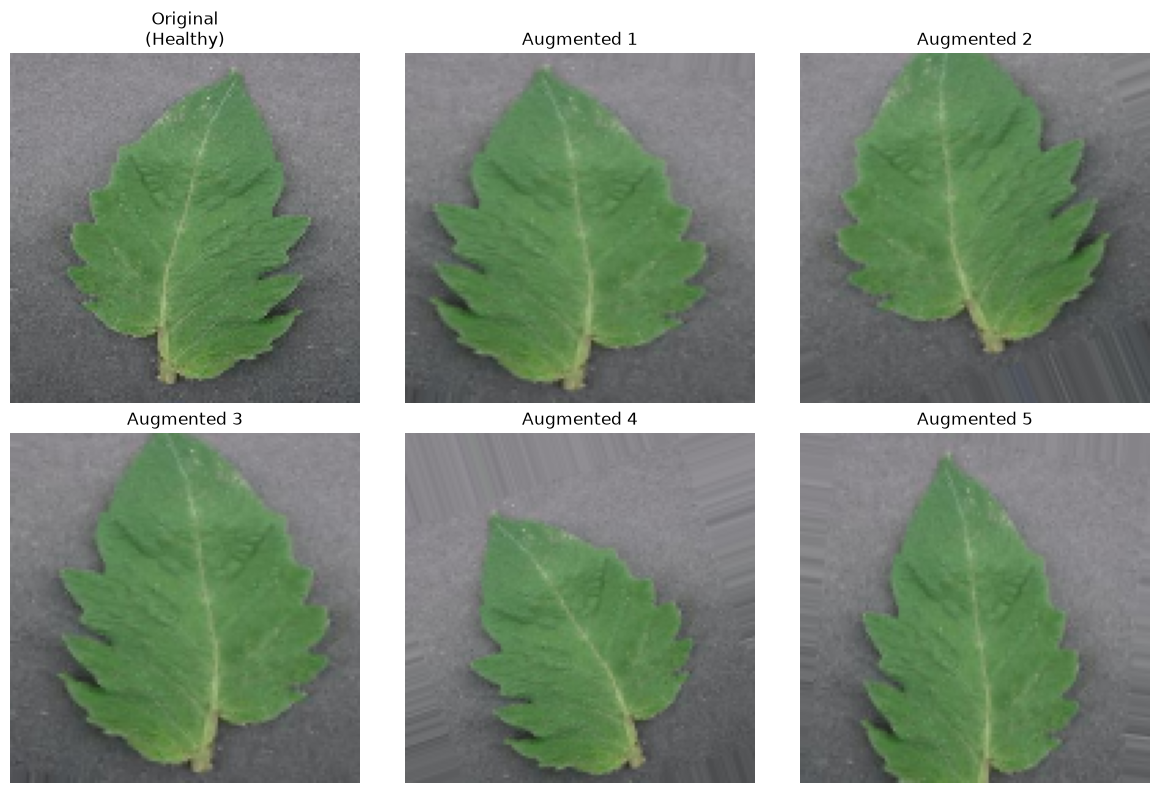

In [28]:
sample_img = X_train[0].reshape(1, 128, 128, 3)
sample_label = ['Early Blight', 'Late Blight', 'Healthy'][np.argmax(y_train[0])]

# Augmentation apply karo
aug_iter = train_datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 3, 1)
plt.imshow(X_train[0])
plt.title(f"Original\n({sample_label})")
plt.axis('off')

# 5 augmented versions
for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(2, 3, i+2)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
# Step 23 — Fresh model banao
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model_v2 = Sequential([
    Input(shape=(128, 128, 3)),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model V2 ready!")
print(f"Total parameters: {model_v2.count_params():,}")

✅ Model V2 ready!
Total parameters: 3,305,027


In [30]:
# Step 24 — Train with augmentation
history_v2 = model_v2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1
)

print("\n✅ Training V2 complete!")

Epoch 1/15


I0000 00:00:1786313098.352541   20222 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


99/99 ━━━━━━━━━━━━━━━━━━━━ 49s 476ms/step - accuracy: 0.6206 - loss: 0.8183 - val_accuracy: 0.7511 - val_loss: 0.5393
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 470ms/step - accuracy: 0.8333 - loss: 0.4177 - val_accuracy: 0.8222 - val_loss: 0.3957
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 468ms/step - accuracy: 0.8571 - loss: 0.3484 - val_accuracy: 0.8474 - val_loss: 0.3720
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 469ms/step - accuracy: 0.8375 - loss: 0.4057 - val_accuracy: 0.7881 - val_loss: 0.5045
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 474ms/step - accuracy: 0.8806 - loss: 0.2932 - val_accuracy: 0.8578 - val_loss: 0.3227
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 47s 472ms/step - accuracy: 0.8917 - loss: 0.2646 - val_accuracy: 0.8533 - val_loss: 0.3093
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 466ms/step - accuracy: 0.8717 - loss: 0.3169 - val_accuracy: 0.8548 - val_loss: 0.3891
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 46s 463ms/step - accuracy: 0.8987 - loss: 0.2465 - val_accuracy: 0.761

In [31]:
# Step 25 — V2 Test evaluation
test_loss_v2, test_acc_v2 = model_v2.evaluate(X_test, y_test, verbose=1)

print("\n" + "="*45)
print("           MODEL COMPARISON")
print("="*45)
print(f"V1 (No Augmentation):  91.85%")
print(f"V2 (With Augmentation): {test_acc_v2*100:.2f}%")
print("="*45)
print(f"Difference: {(test_acc_v2*100 - 91.85):+.2f}%")

W0000 00:00:1786313864.868627   20222 cpu_allocator_impl.cc:82] Allocation of 132710400 exceeds 10% of free system memory.


22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9230 - loss: 0.2283

           MODEL COMPARISON
V1 (No Augmentation):  91.85%
V2 (With Augmentation): 92.30%
Difference: +0.45%


In [32]:
y_pred_v2 = np.argmax(model_v2.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = ['Early Blight', 'Late Blight', 'Healthy']

print("V2 Classification Report:")
print("="*55)
print(classification_report(y_true, y_pred_v2, target_names=class_names))


V2 Classification Report:
              precision    recall  f1-score   support

Early Blight       0.84      0.85      0.84       150
 Late Blight       0.95      0.90      0.92       286
     Healthy       0.95      1.00      0.97       239

    accuracy                           0.92       675
   macro avg       0.91      0.92      0.91       675
weighted avg       0.92      0.92      0.92       675



In [33]:
# Step 27 — Transfer Learning with MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input

# Pre-trained model load karo (ImageNet weights)
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,        # Apni classification layer add karenge
    weights='imagenet'        # 14 million images pe trained
)

# Base model freeze karo (weights change na ho)
base_model.trainable = False

# Apna model banao
model_v3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model_v3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Transfer Learning Model Ready!")
print(f"\nTotal parameters:     {model_v3.count_params():,}")
print(f"Trainable parameters: {sum([np.prod(v.shape) for v in model_v3.trainable_weights]):,}")
print(f"Frozen parameters:    {sum([np.prod(v.shape) for v in model_v3.non_trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✅ Transfer Learning Model Ready!

Total parameters:     2,422,339
Trainable parameters: 164,355
Frozen parameters:    2,257,984


In [34]:
# Step 28 — Train V3 with augmentation
history_v3 = model_v3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

print("\n✅ V3 Training complete!")

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 40s 359ms/step - accuracy: 0.8286 - loss: 0.4160 - val_accuracy: 0.8770 - val_loss: 0.3434
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 347ms/step - accuracy: 0.8937 - loss: 0.2576 - val_accuracy: 0.8978 - val_loss: 0.2876
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 344ms/step - accuracy: 0.9146 - loss: 0.2079 - val_accuracy: 0.8830 - val_loss: 0.3141
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 339ms/step - accuracy: 0.9302 - loss: 0.1793 - val_accuracy: 0.9111 - val_loss: 0.2387
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 340ms/step - accuracy: 0.9365 - loss: 0.1733 - val_accuracy: 0.9067 - val_loss: 0.2711
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 337ms/step - accuracy: 0.9365 - loss: 0.1626 - val_accuracy: 0.9067 - val_loss: 0.2520
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step - accuracy: 0.9470 - loss: 0.1431 - val_accuracy: 0.9304 - val_loss: 0.1775
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 344ms/step - accuracy: 0.9463 - loss: 0.1425 - val_accu

In [35]:
# Step 29 — V3 Final evaluation
test_loss_v3, test_acc_v3 = model_v3.evaluate(X_test, y_test, verbose=1)

print("\n" + "="*50)
print("           FINAL COMPARISON")
print("="*50)
print(f"V1 (Basic CNN):        91.85%")
print(f"V2 (CNN + Augment):    92.30%")
print(f"V3 (Transfer Learn):   {test_acc_v3*100:.2f}%")
print("="*50)
print(f"V3 improvement over V1: {(test_acc_v3*100 - 91.85):+.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.9007 - loss: 0.2484

           FINAL COMPARISON
V1 (Basic CNN):        91.85%
V2 (CNN + Augment):    92.30%
V3 (Transfer Learn):   90.07%
V3 improvement over V1: -1.78%


In [36]:
y_pred_v3 = np.argmax(model_v3.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = ['Early Blight', 'Late Blight', 'Healthy']

print("V3 Classification Report:")
print("="*55)
print(classification_report(y_true, y_pred_v3, target_names=class_names))


V3 Classification Report:
              precision    recall  f1-score   support

Early Blight       0.78      0.83      0.80       150
 Late Blight       0.90      0.95      0.92       286
     Healthy       1.00      0.89      0.94       239

    accuracy                           0.90       675
   macro avg       0.89      0.89      0.89       675
weighted avg       0.91      0.90      0.90       675



In [37]:
# Step 31 — Save V2 as final model
model_v2.save("plant_disease_final.keras")

import os
size_mb = os.path.getsize("plant_disease_final.keras") / (1024 * 1024)

print("✅ Final model saved!")
print(f"📁 File: plant_disease_final.keras")
print(f"📊 Size: {size_mb:.2f} MB")
print(f"🎯 Accuracy: 92.30%")

✅ Final model saved!
📁 File: plant_disease_final.keras
📊 Size: 37.87 MB
🎯 Accuracy: 92.30%
